In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr,spearmanr

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [142]:
df1=pd.read_excel('./data/附件1.xlsx')
df2=pd.read_csv('./data/附件2.csv', encoding='utf-8')

df1.info(),df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   单品编码    251 non-null    int64
 1   单品名称    251 non-null    str  
 2   分类编码    251 non-null    int64
 3   分类名称    251 non-null    str  
dtypes: int64(2), str(2)
memory usage: 8.0 KB
<class 'pandas.DataFrame'>
RangeIndex: 127935 entries, 0 to 127934
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   销售日期        127935 non-null  str    
 1   扫码销售时间      127935 non-null  str    
 2   单品编码        127935 non-null  int64  
 3   销量(千克)      127935 non-null  float64
 4   销售单价(元/千克)  127935 non-null  float64
 5   销售类型        127935 non-null  str    
 6   是否打折销售      127935 non-null  str    
dtypes: float64(2), int64(1), str(4)
memory usage: 6.8 MB


(None, None)

In [143]:
df2.to_csv('./data/附件2.csv',index=False,encoding='utf-8-sig')

In [144]:
df_group_by_date_and_item=df2.groupby(by=['销售日期','单品编码']).agg({'销量(千克)':'sum'})
df_group_by_date_and_item

销量(千克)
销售日期       单品编码                   
2020-07-01 102900005115762   6.841
           102900005115779  41.966
           102900005115786  11.352
           102900005115793   4.288
           102900005115823  11.476
...                            ...
2020-10-29 102900011013274   5.000
           102900011018095   6.000
           102900051000463   2.152
           102900051004294   1.730
           102900051010455   1.684

[4960 rows x 1 columns]

In [145]:
group_by=df2.groupby('单品编码',as_index=False).agg({'销量(千克)':'sum'})
temp=df2.groupby('单品编码',as_index=False).agg({'销量(千克)':'mean'}).iloc[:,1].values
temp_df=pd.Series(temp,name='平均销量(千克)')
group_by=pd.concat([group_by,temp_df],axis=1)
group_by

,单品编码,销量(千克),平均销量(千克)
0,102900005115250,1.666,0.238000
1,102900005115762,519.025,0.489646
2,102900005115779,3366.454,0.373262
3,102900005115786,1151.059,0.443056
4,102900005115793,605.837,0.437743
...,...,...,...
71,102900051009336,13.547,0.111959
72,102900051010455,2450.091,0.539787
73,106931885000035,4.000,1.000000
74,106956146480197,250.000,1.000000


In [146]:
group_by.to_csv('./data/附件2_group_by.csv',index=True,encoding='utf-8-sig')

In [147]:
df1_merge=pd.merge(df1,group_by,on='单品编码',how='left')
df1_merge.to_csv('./data/附件1_merge.csv',index=False,encoding='utf-8-sig')
df1_merge

,单品编码,单品名称,分类编码,分类名称,销量(千克),平均销量(千克)
0,102900005115168,牛首生菜,1011010101,花叶类,NaN,NaN
1,102900005115199,四川红香椿,1011010101,花叶类,NaN,NaN
2,102900005115625,本地小毛白菜,1011010101,花叶类,NaN,NaN
3,102900005115748,白菜苔,1011010101,花叶类,NaN,NaN
4,102900005115762,苋菜,1011010101,花叶类,519.025,0.489646
...,...,...,...,...,...,...
246,106958851400125,海鲜菇(袋)(4),1011010801,食用菌,NaN,NaN
247,106971533450003,海鲜菇(包),1011010801,食用菌,NaN,NaN
248,106971533455008,海鲜菇(袋)(3),1011010801,食用菌,NaN,NaN
249,106973223300667,虫草花(盒)(2),1011010801,食用菌,NaN,NaN


In [148]:
df1_merge.loc[pd.isnull(df1_merge['销量(千克)']), ['销量(千克)','平均销量(千克)']] = 0
df1_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   单品编码      251 non-null    int64  
 1   单品名称      251 non-null    str    
 2   分类编码      251 non-null    int64  
 3   分类名称      251 non-null    str    
 4   销量(千克)    251 non-null    float64
 5   平均销量(千克)  251 non-null    float64
dtypes: float64(2), int64(2), str(2)
memory usage: 11.9 KB


In [149]:
df1_merge.to_csv('./data/附件1_merge.csv',index=False,encoding='utf-8-sig')
df1_merge.to_excel('./data/附件1_merge.xlsx',index=False)

In [150]:
#透视表操作
total_result=df1_merge.pivot_table(index=['单品名称','单品编码'],columns=['分类名称'],values=['销量(千克)','平均销量(千克)'],aggfunc=np.sum)

In [151]:
total_result.to_excel('./data/附件1_merge_pivot_table.xlsx',index=True)


In [152]:
total_result.to_csv('./data/附件1_merge_pivot_table.csv',index=True,encoding='utf-8-sig')

In [153]:
#上面是数据预处理

pivotal_result=total_result.copy()
pivotal_result

平均销量(千克)                                      销量(千克)  \
分类名称                        水生根茎类       花叶类 花菜类  茄类      辣椒类       食用菌  水生根茎类   
单品名称     单品编码                                                                   
七彩椒(1)   102900005117209      NaN       NaN NaN NaN  0.30369       NaN    NaN   
七彩椒(2)   102900011032343      NaN       NaN NaN NaN  0.00000       NaN    NaN   
七彩椒(份)   102900011031735      NaN       NaN NaN NaN  0.00000       NaN    NaN   
上海青      102900005115823      NaN  0.432029 NaN NaN      NaN       NaN    NaN   
上海青(份)   102900011030141      NaN  0.000000 NaN NaN      NaN       NaN    NaN   
...                           ...       ...  ..  ..      ...       ...    ...   
黑牛肝菌     102900011011058      NaN       NaN NaN NaN      NaN  0.000000    NaN   
黑牛肝菌(盒)  102900011030622      NaN       NaN NaN NaN      NaN  0.000000    NaN   
黑皮鸡枞菌    102900011012871      NaN       NaN NaN NaN      NaN  0.160667    NaN   
黑皮鸡枞菌(盒) 102900011030639      NaN       NaN NaN NaN      NaN  0.000000    NaN   
龙牙菜      102900011035764      NaN  0.000000 NaN NaN      NaN       NaN    NaN   

                                                           
分类名称                           花叶类 花菜类  茄类     辣椒类    食用菌  
单品名称     单品编码                                              
七彩椒(1)   102900005117209       NaN NaN NaN  75.315    NaN  
七彩椒(2)   102900011032343       NaN NaN NaN   0.000    NaN  
七彩椒(份)   102900011031735       NaN NaN NaN   0.000    NaN  
上海青      102900005115823  1929.009 NaN NaN     NaN    NaN  
上海青(份)   102900011030141     0.000 NaN NaN     NaN    NaN  
...                            ...  ..  ..     ...    ...  
黑牛肝菌     102900011011058       NaN NaN NaN     NaN  0.000  
黑牛肝菌(盒)  102900011030622       NaN NaN NaN     NaN  0.000  
黑皮鸡枞菌    102900011012871       NaN NaN NaN     NaN  0.482  
黑皮鸡枞菌(盒) 102900011030639       NaN NaN NaN     NaN  0.000  
龙牙菜      102900011035764     0.000 NaN NaN     NaN    NaN  

[251 rows x 12 columns]

In [154]:
total_result['平均销量(千克)'].to_csv('./data/附件1_merge_pivot_table_平均销量.csv',index=True,encoding='utf-8-sig')

In [155]:
pivotal_result=pd.read_csv('./data/附件1_merge_pivot_table_平均销量.csv',index_col=0,encoding='utf-8-sig')
pivotal_result['单品编码']=pivotal_result['单品编码'].astype('category')
pivotal_result.describe()

,水生根茎类,花叶类,花菜类,茄类,辣椒类,食用菌
count,19.000000,100.000000,5.000000,10.000000,45.000000,72.000000
mean,0.219904,0.124249,0.192880,0.273431,0.076981,0.180567
std,0.446623,0.228253,0.265605,0.293349,0.131248,0.352875
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.217167,0.000000,0.000000
75%,0.289863,0.273600,0.442422,0.522638,0.145256,0.201119
max,1.875000,1.029480,0.521976,0.628237,0.379667,1.212308


In [156]:
pivotal_result.loc[:,'水生根茎类':'食用菌'].var()

水生根茎类    0.199472
花叶类      0.052099
花菜类      0.070546
茄类       0.086054
辣椒类      0.017226
食用菌      0.124521
dtype: float64

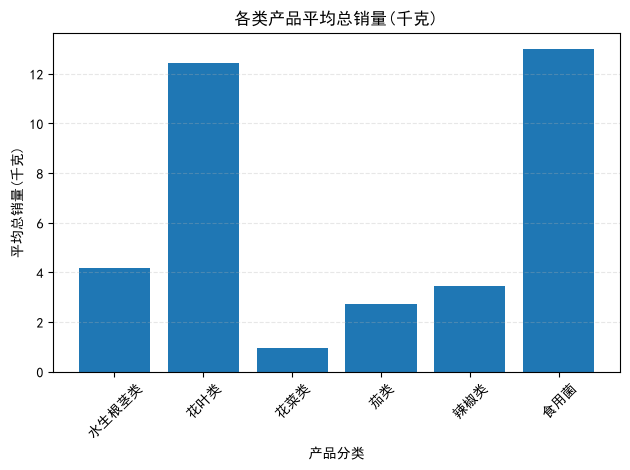

In [157]:
sum_result=pivotal_result.loc[:,'水生根茎类':'食用菌'].sum(axis=0)
plt.bar(sum_result.index,sum_result.values)
plt.title('各类产品平均总销量(千克)')
plt.xlabel('产品分类')
plt.ylabel('平均总销量(千克)')  
plt.xticks(rotation=45)
plt.tight_layout()  # 自动调整子图参数，使之填充整个图像区域
plt.grid(axis='y', linestyle='--', alpha=0.3)  # 添加网格线
plt.savefig('./figure/各类产品平均总销量(千克).pdf', dpi=300)  # 保存图像
plt.show()

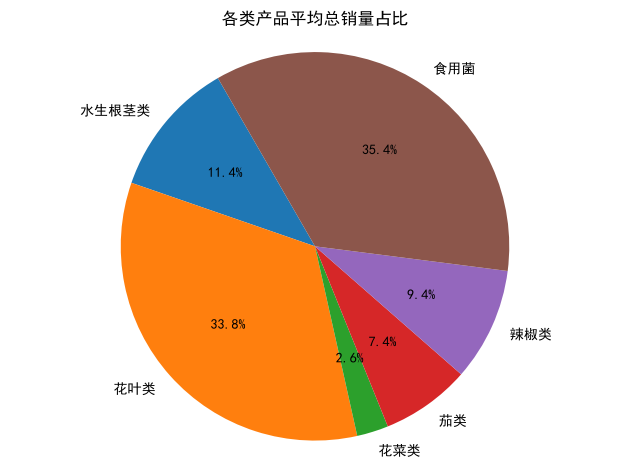

In [158]:
plt.pie(sum_result.values, labels=sum_result.index, autopct='%1.1f%%', startangle=120)
plt.title('各类产品平均总销量占比')
plt.axis('equal')  # 保证饼图是圆形
plt.tight_layout()  # 自动调整子图参数，使之填充整个图像区域
plt.savefig('./figure/各类产品平均总销量占比.pdf', dpi=300)
plt.show()

In [159]:
df2=pd.read_csv('./data/附件2.csv', encoding='utf-8')
df1=pd.read_excel('./data/附件1.xlsx')
df2

,销售日期,扫码销售时间,单品编码,销量(千克),销售单价(元/千克),销售类型,是否打折销售
0,2020-07-01,09:15:07.924,102900005117056,0.396,7.6,销售,否
1,2020-07-01,09:17:27.295,102900005115960,0.849,3.2,销售,否
2,2020-07-01,09:17:33.905,102900005117056,0.409,7.6,销售,否
3,2020-07-01,09:19:45.450,102900005115823,0.421,10.0,销售,否
4,2020-07-01,09:20:23.686,102900005115908,0.539,8.0,销售,否
...,...,...,...,...,...,...,...
127930,2020-10-29,18:14:13.636,102900011006689,0.477,4.0,销售,否
127931,2020-10-29,18:15:46.068,102900011008164,0.334,6.0,销售,否
127932,2020-10-29,18:15:51.201,102900005116714,0.458,9.2,销售,否
127933,2020-10-29,18:15:52.717,102900005118817,0.426,8.0,销售,否


In [160]:
merge_df=pd.merge(df1,df2,on='单品编码',how='left')
merge_df.to_excel('./data/附件1_附件2_merge_df.xlsx',index=False)
merge_df

,单品编码,单品名称,分类编码,分类名称,销售日期,扫码销售时间,销量(千克),销售单价(元/千克),销售类型,是否打折销售
0,102900005115168,牛首生菜,1011010101,花叶类,NaN,NaN,NaN,NaN,NaN,NaN
1,102900005115199,四川红香椿,1011010101,花叶类,NaN,NaN,NaN,NaN,NaN,NaN
2,102900005115625,本地小毛白菜,1011010101,花叶类,NaN,NaN,NaN,NaN,NaN,NaN
3,102900005115748,白菜苔,1011010101,花叶类,NaN,NaN,NaN,NaN,NaN,NaN
4,102900005115762,苋菜,1011010101,花叶类,2020-07-01,09:33:09.579,0.686,6.0,销售,否
...,...,...,...,...,...,...,...,...,...,...
128105,106958851400125,海鲜菇(袋)(4),1011010801,食用菌,NaN,NaN,NaN,NaN,NaN,NaN
128106,106971533450003,海鲜菇(包),1011010801,食用菌,NaN,NaN,NaN,NaN,NaN,NaN
128107,106971533455008,海鲜菇(袋)(3),1011010801,食用菌,NaN,NaN,NaN,NaN,NaN,NaN
128108,106973223300667,虫草花(盒)(2),1011010801,食用菌,NaN,NaN,NaN,NaN,NaN,NaN


In [161]:
relation_table=merge_df.pivot_table(index='销售日期',columns='分类名称',values='销量(千克)',aggfunc=np.sum)
relation_table.to_csv('./data/产品种类销售相关分析.csv',index=True,encoding='utf-8-sig')
relation_table

分类名称,水生根茎类,花叶类,花菜类,茄类,辣椒类,食用菌
销售日期,,,,,,
2020-07-01,4.850,205.402,46.640,35.374,76.715,35.365
2020-07-02,4.600,198.362,43.943,32.199,66.064,48.510
2020-07-03,9.572,190.779,42.076,35.896,64.253,42.442
2020-07-04,5.439,236.587,55.662,57.067,81.282,47.262
2020-07-05,4.019,223.899,55.474,61.816,98.496,73.213
...,...,...,...,...,...,...
2020-10-25,71.160,223.397,43.114,30.136,72.537,104.160
2020-10-26,20.666,157.373,22.371,10.797,45.439,62.363
2020-10-27,21.273,154.566,23.305,13.444,45.479,56.508


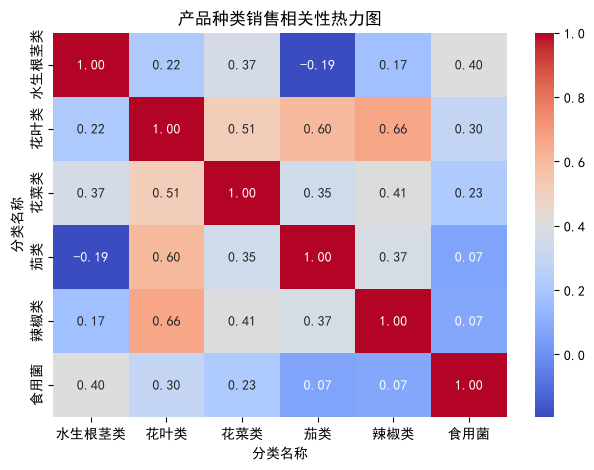

In [ ]:
relation_table.corr()
sns.heatmap(relation_table.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('产品种类销售相关性热力图(pearsonr相关系数)')
plt.tight_layout()  # 自动调整子图参数，使之填充整个图像区域
plt.savefig('./figure/产品种类销售相关性热力图.pdf', dpi=300)  # 保存图像
plt.show()

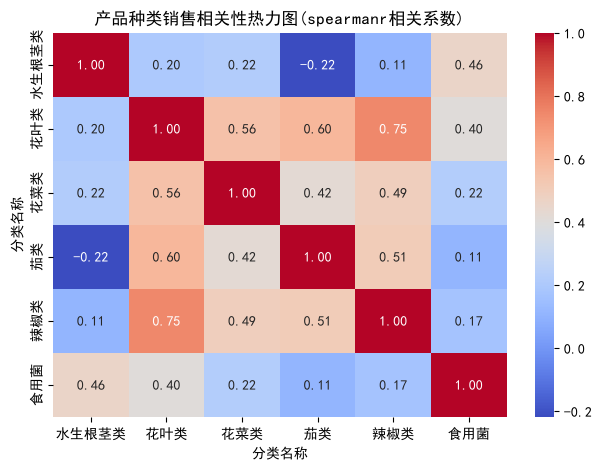

In [170]:
relation_table.corr()
sns.heatmap(relation_table.corr(method='spearman'), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('产品种类销售相关性热力图(spearmanr相关系数)')
plt.tight_layout()  # 自动调整子图参数，使之填充整个图像区域
plt.savefig('./figure/产品种类销售相关性热力图.pdf', dpi=300)  # 保存图像
plt.show()

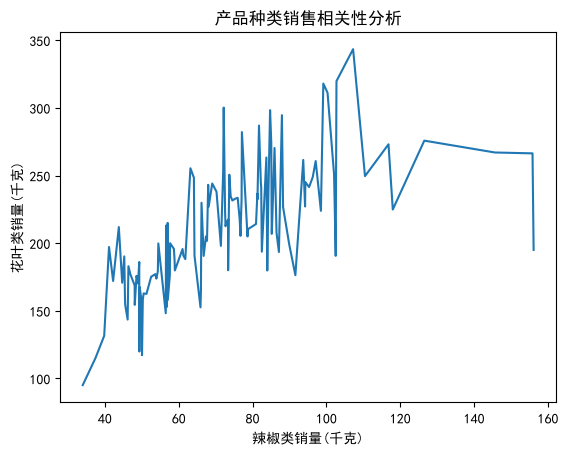

In [163]:
pepper=relation_table['辣椒类'].values
cauliflower=relation_table['花叶类'].values

pepper_=np.sort(pepper)
# print(cauliflower)
cauliflower=cauliflower[np.argsort(pepper)]
# cauliflower

plt.plot(pepper_,cauliflower)
plt.xlabel('辣椒类销量(千克)')
plt.ylabel('花叶类销量(千克)')
plt.title('产品种类销售相关性分析')
plt.show()

In [169]:
pearson_corr, pearson_p = pearsonr(relation_table['辣椒类'], relation_table['花叶类'])
spearman_corr, spearman_p = spearmanr(relation_table['辣椒类'], relation_table['花叶类'])
print(f"Pearson correlation coefficient: {pearson_corr:.4f}, p-value: {pearson_p:.4f}")

Pearson correlation coefficient: 0.6631, p-value: 0.0000


In [165]:
pearsonr_corr,pearsonr_p = pearsonr(relation_table['茄类'],relation_table['花叶类'])

if pearsonr_p < 0.05:
    print(f'有百分之{(1-pearsonr_p)*100:.2f}的置信度认为茄类和花叶类销量之间存在显著的线性相关关系，Pearson相关系数为{pearsonr_corr:.4f}')
else:
    print(f'没有足够的证据认为茄类和花叶类销量之间存在显著的线性相关关系，Pearson相关系数为{pearsonr_corr:.4f}')

有百分之100.00的置信度认为茄类和花叶类销量之间存在显著的线性相关关系，Pearson相关系数为0.5961


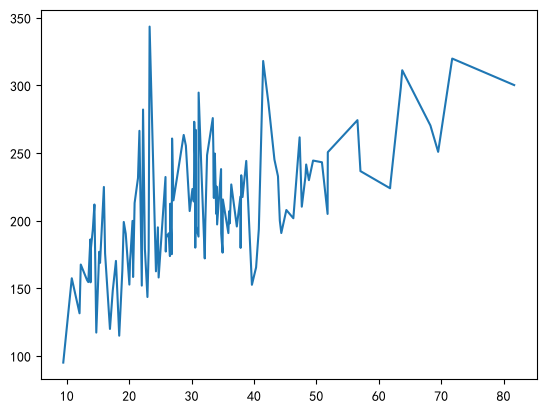

In [166]:
aggplant=relation_table.loc[:,'茄类'].values.copy()
cauliflower=relation_table.loc[:,'花叶类'].values.copy()

cauliflower=cauliflower[np.argsort(aggplant)]
aggplant_=np.sort(aggplant)

plt.plot(aggplant_,cauliflower)
plt.show()

In [168]:
for i in relation_table.columns:
    for j in relation_table.columns:
        if i!=j:
            spearman_corr,spearman_p=spearmanr(relation_table[i],relation_table[j])
            if spearman_p < 0.05:
                print(f'有百分之{(1-spearman_p)*100:.2f}的置信度认为{i}和{j}销量之间存在显著的相关关系，Spearman相关系数为{spearman_corr:.4f}')
            

有百分之96.98的置信度认为水生根茎类和花叶类销量之间存在显著的相关关系，Spearman相关系数为0.1972
有百分之98.24的置信度认为水生根茎类和花菜类销量之间存在显著的相关关系，Spearman相关系数为0.2155
有百分之98.42的置信度认为水生根茎类和茄类销量之间存在显著的相关关系，Spearman相关系数为-0.2190
有百分之100.00的置信度认为水生根茎类和食用菌销量之间存在显著的相关关系，Spearman相关系数为0.4611
有百分之96.98的置信度认为花叶类和水生根茎类销量之间存在显著的相关关系，Spearman相关系数为0.1972
有百分之100.00的置信度认为花叶类和花菜类销量之间存在显著的相关关系，Spearman相关系数为0.5571
有百分之100.00的置信度认为花叶类和茄类销量之间存在显著的相关关系，Spearman相关系数为0.5975
有百分之100.00的置信度认为花叶类和辣椒类销量之间存在显著的相关关系，Spearman相关系数为0.7466
有百分之100.00的置信度认为花叶类和食用菌销量之间存在显著的相关关系，Spearman相关系数为0.4021
有百分之98.24的置信度认为花菜类和水生根茎类销量之间存在显著的相关关系，Spearman相关系数为0.2155
有百分之100.00的置信度认为花菜类和花叶类销量之间存在显著的相关关系，Spearman相关系数为0.5571
有百分之100.00的置信度认为花菜类和茄类销量之间存在显著的相关关系，Spearman相关系数为0.4210
有百分之100.00的置信度认为花菜类和辣椒类销量之间存在显著的相关关系，Spearman相关系数为0.4923
有百分之98.47的置信度认为花菜类和食用菌销量之间存在显著的相关关系，Spearman相关系数为0.2200
有百分之98.42的置信度认为茄类和水生根茎类销量之间存在显著的相关关系，Spearman相关系数为-0.2190
有百分之100.00的置信度认为茄类和花叶类销量之间存在显著的相关关系，Spearman相关系数为0.5975
有百分之100.00的置信度认为茄类和花菜类销量之间存在显著的相关关系，Spearman相关系数为0.4210
有百分之100.00的置信度认为茄类和辣椒类销量之间存在